# 06 - Model Interpretability — SHAP

Análisis de interpretabilidad del modelo XGBoost usando SHAP
(SHapley Additive exPlanations). El objetivo es entender qué
features determinan cada predicción, tanto a nivel global
como a nivel de observación individual.

## 1. Carga del modelo y los datos

In [17]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import classification_report

X_test = pd.read_csv('../data/X_test.csv')
y_test = pd.read_csv('../data/y_test.csv').squeeze()

checkpoint = joblib.load('../data/xgboost_final.pkl')

# Maneja ambos formatos
if isinstance(checkpoint, dict):
    modelo = checkpoint['modelo']
else:
    modelo = checkpoint

print("Modelo y datos cargados")
print(f"X_test: {X_test.shape}")

Modelo y datos cargados
X_test: (4524, 4)


## 2. SHAP Values — TreeExplainer

Se usa TreeExplainer, el explicador optimizado para modelos
basados en árboles. Calcula los SHAP values exactos aprovechando
la estructura del árbol, a diferencia del explicador genérico
que usa aproximaciones por muestreo.

Cada SHAP value representa la contribución marginal de una feature
a la predicción de una observación específica, con signo positivo
indicando contribución hacia la clase peligroso y negativo hacia
no peligroso.

In [18]:
explainer = shap.TreeExplainer(modelo)
shap_values = explainer.shap_values(X_test)

print("SHAP values calculados")
print(f"Shape de shap_values: {shap_values.shape}")

SHAP values calculados
Shape de shap_values: (4524, 4)


## 3. Summary Plot — importancia global de features

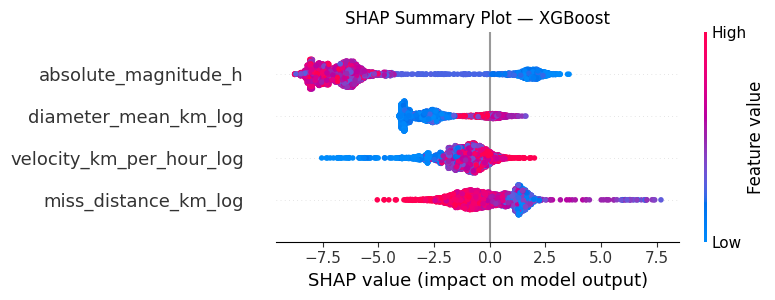

In [19]:
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary Plot — XGBoost')
plt.tight_layout()
plt.show()

In [20]:
y_pred = modelo.predict(X_test)

# Falsos negativos: era peligroso pero el modelo dijo no peligroso
falsos_negativos = X_test[(y_test.values == True) & (y_pred == False)]

print(f"Total falsos negativos: {len(falsos_negativos)}")
print(falsos_negativos.head())

Total falsos negativos: 51
     absolute_magnitude_h  diameter_mean_km_log  velocity_km_per_hour_log  \
116             -0.960957              0.431244                  0.885965   
148             -1.367352              1.058868                  1.956744   
158             -2.012112              2.668076                  0.502635   
238             -1.625256              1.599943                  1.164415   
262             -1.078186              0.587571                  0.466116   

     miss_distance_km_log  
116              0.790470  
148              0.064049  
158              0.258504  
238              1.210241  
262              1.142535  


## 4. Waterfall Plot — análisis de un falso negativo

Se selecciona un falso negativo para análisis individual: un asteroide
clasificado como no peligroso por el modelo siendo peligroso en realidad.
El waterfall plot descompone la predicción en las contribuciones
individuales de cada feature.

In [21]:
# Tomamos el primer falso negativo
idx = falsos_negativos.index[0]
asteroide = X_test.loc[idx]

print("Asteroide analizado:")
print(asteroide)
print(f"\nEra peligroso: {y_test.loc[idx]}")
print(f"El modelo predijo: {modelo.predict(asteroide.values.reshape(1,-1))[0]}")

Asteroide analizado:
absolute_magnitude_h       -0.960957
diameter_mean_km_log        0.431244
velocity_km_per_hour_log    0.885965
miss_distance_km_log        0.790470
Name: 116, dtype: float64

Era peligroso: True
El modelo predijo: 0


### ¿Por qué el modelo no lo detectó?

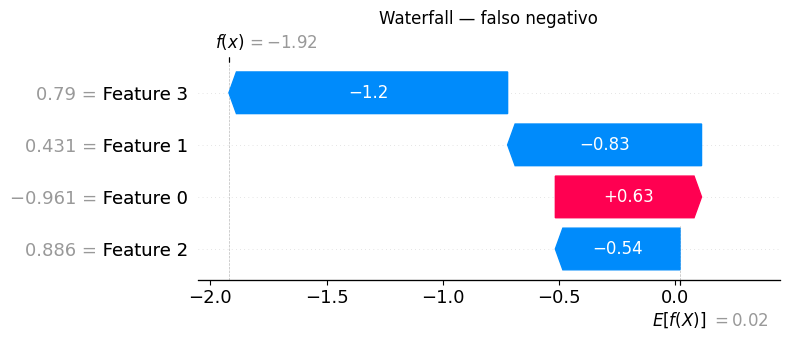

In [22]:
explainer_single = shap.TreeExplainer(modelo)
shap_single = explainer_single(asteroide.values.reshape(1,-1))

shap.plots.waterfall(shap_single[0], show=False)
plt.title('Waterfall — falso negativo')
plt.tight_layout()
plt.show()

### Conclusión del análisis

El análisis revela el patrón de error estructural del modelo: cuando
un asteroide grande (absolute_magnitude_h bajo, contribución +0.63)
presenta miss_distance y velocity por encima del promedio, las
contribuciones negativas de ambas variables anulan la señal de tamaño,
resultando en una predicción incorrecta.

Este tipo de error no se resuelve con más datos del mismo tipo. El modelo
requeriría features orbitales adicionales (excentricidad, inclinación,
semieje mayor) para distinguir correctamente estos casos.

## 5. Ajuste del umbral de decisión

El umbral de decisión por defecto es 0.50. En el contexto de detección
de asteroides peligrosos, el costo de un falso negativo es
significativamente mayor al de un falso positivo. Se evalúan umbrales
entre 0.20 y 0.50 para analizar el trade-off precision/recall.

In [23]:
# Probabilidades en lugar de clases
y_proba = modelo.predict_proba(X_test)[:, 1]

print("Comparación de umbrales:\n")

for umbral in [0.50, 0.40, 0.30, 0.20]:
    y_pred_umbral = (y_proba >= umbral).astype(int)
    reporte = classification_report(y_test, y_pred_umbral,
                                   target_names=['No peligroso', 'Peligroso'],
                                   output_dict=True)
    print(f"Umbral {umbral}:")
    print(f"  Precision: {reporte['Peligroso']['precision']:.3f}")
    print(f"  Recall:    {reporte['Peligroso']['recall']:.3f}")
    print(f"  F1:        {reporte['Peligroso']['f1-score']:.3f}")
    print()

Comparación de umbrales:

Umbral 0.5:
  Precision: 0.414
  Recall:    0.798
  F1:        0.545

Umbral 0.4:
  Precision: 0.396
  Recall:    0.841
  F1:        0.538

Umbral 0.3:
  Precision: 0.379
  Recall:    0.881
  F1:        0.530

Umbral 0.2:
  Precision: 0.370
  Recall:    0.929
  F1:        0.529



### Umbral seleccionado: 0.20

En el contexto de detección de asteroides peligrosos, el costo de un falso
negativo es significativamente mayor al de un falso positivo. Se evaluaron
umbrales entre 0.20 y 0.50 para analizar el trade-off precision/recall.

Selección basada en criterio de negocio, no en optimización de F1.
Con umbral 0.20 el modelo detecta el 92.9% de los asteroides peligrosos
reales (recall 0.929) con una precision de 0.370. La reducción de
precision es un costo aceptable dado el contexto crítico de la aplicación.

In [24]:
joblib.dump({'modelo': modelo, 'umbral': 0.20}, '../data/xgboost_final.pkl')
print("Modelo y umbral guardados")

Modelo y umbral guardados
